In [8]:
# Import required libraries
from pathlib import Path
import pandas as pd

# Importar dataset
DATA_PATH = Path.cwd() / "seattle-weather-dataset.csv"

data = pd.read_csv(DATA_PATH)
df = pd.DataFrame(data)

print("Sample data:")
df.head(5)

Sample data:


,date,precipitation,temp_max,temp_min,wind,weather
0,1/1/2012,0.0,12.8,5.0,4.7,drizzle
1,1/2/2012,10.9,10.6,2.8,4.5,rain
2,1/3/2012,0.8,11.7,7.2,2.3,rain
3,1/4/2012,20.3,12.2,5.6,4.7,rain
4,1/5/2012,1.3,8.9,2.8,6.1,rain


In [9]:
df = df.drop(columns=['date'])
df

,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,drizzle
1,10.9,10.6,2.8,4.5,rain
2,0.8,11.7,7.2,2.3,rain
3,20.3,12.2,5.6,4.7,rain
4,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...
1456,8.6,4.4,1.7,2.9,rain
1457,1.5,5.0,1.7,1.3,rain
1458,0.0,7.2,0.6,2.6,fog
1459,0.0,5.6,-1.0,3.4,sun


In [ ]:
import plotly.express as px

# Mapear la frecuencia de las clases para entender a qué nos estamos enfrentando
fig = px.bar(df['weather'].value_counts().reset_index(name='count'),
             x='weather', y='count',
             labels={'weather': 'Weather Type', 'count': 'Frequency'},
             title=' Frequency of Weather Classes')
fig.show()


In [12]:
from sklearn.utils import resample
import pandas as pd
import plotly.express as px

# Oversample minority classes to match the majority
max_count = df['weather'].value_counts().max() # This line finds the largest class count in the 'weather' column. # It counts how many samples belong to each class, then stores the maximum value.

# This code performs oversampling for each weather class to create a balanced dataset.
# It groups the dataframe by 'weather' and then resamples each group (class) so that
# all classes have the same number of samples as the majority class (max_count).
# 'replace=True' allows duplicate samples, and 'random_state=42' ensures reproducibility.
balanced_parts = [
    resample(g, replace=True, n_samples=max_count, random_state=42)
    for _, g in df.groupby('weather')
]
# This line combines all oversampled class subsets (stored in balanced_parts)
# into one DataFrame using pd.concat(). Then, it randomly shuffles the rows
# (sample(frac=1)) to mix the classes evenly.
# 'random_state=42' ensures reproducibility, and reset_index(drop=True)
# resets the index numbers after concatenation.
balanced_df = pd.concat(balanced_parts).sample(frac=1, random_state=42).reset_index(drop=True)

# Plot interactive bar chart of balanced classes
fig = px.bar(
    balanced_df['weather'].value_counts().reset_index(name='count'),
    x='weather', y='count',
    labels={'weather': 'Weather Type', 'count': 'Frequency'},
    title='Balanced Frequency of Weather Class'
)
fig.show()


Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Best Hyperparameters: {'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


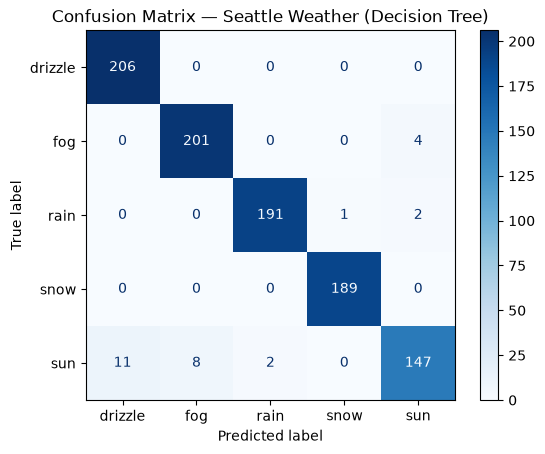

Classification Report:
              precision    recall  f1-score   support

     drizzle       0.95      1.00      0.97       206
         fog       0.96      0.98      0.97       205
        rain       0.99      0.98      0.99       194
        snow       0.99      1.00      1.00       189
         sun       0.96      0.88      0.92       168

    accuracy                           0.97       962
   macro avg       0.97      0.97      0.97       962
weighted avg       0.97      0.97      0.97       962



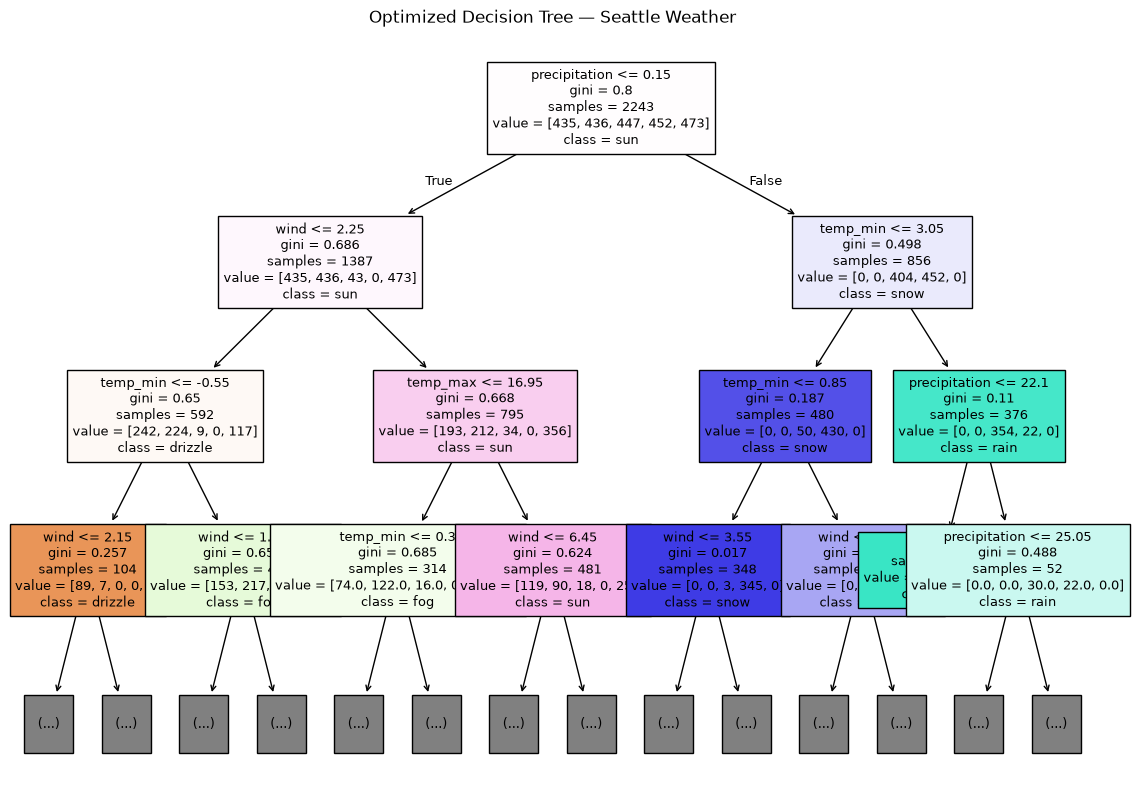

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc

# Define features/target from balanced_df
#    Keep only numeric features for X; 'weather' is the multiclass target
num_cols = balanced_df.select_dtypes(include='number').columns
X = balanced_df[num_cols].copy() #.copy() ensures that X is a compeltely seperate object without unintentionally altering balanced_df
y = balanced_df['weather'].copy()

# Train/test split (balanced_df is already balanced)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Baseline model + hyperparameter optimization (GridSearchCV)
dtree = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 4, 6, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'max_leaf_nodes': [None, 5, 10, 20]
}
grid_search = GridSearchCV(estimator=dtree,param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1,verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# Predictions, confusion matrix, and classification report
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix — Seattle Weather (Decision Tree)")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred, labels=best_model.classes_))

# Visualize the optimized decision tree
plt.figure(figsize=(14, 10))
plot_tree(best_model, feature_names=X.columns, class_names=best_model.classes_, filled=True,max_depth=3, fontsize=9)
plt.title("Optimized Decision Tree — Seattle Weather")
plt.show()




GridSearchCV is training and validating 720 different hyperparameter combinations, and for each combination, it runs a 5-fold cross-validation.
That results in 3600 model training runs in total — a complete and exhaustive search for the best parameter set.

Dataset successfully loaded!
   precipitation  temp_max  temp_min  wind  weather
0            0.0      12.8       5.0   4.7  drizzle
1           10.9      10.6       2.8   4.5     rain
2            0.8      11.7       7.2   2.3     rain
3           20.3      12.2       5.6   4.7     rain
4            1.3       8.9       2.8   6.1     rain

Original class distribution:
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64

Training class distribution:
weather
sun        448
rain       448
fog         71
drizzle     37
snow        18
Name: count, dtype: int64

Test class distribution:
weather
rain       193
sun        192
fog         30
drizzle     16
snow         8
Name: count, dtype: int64
Number of candidates: 432
Total number of fits with 5-fold CV: 2160
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best Hyperparameters:
{'model__criterion': 'entropy', 'model__max_depth': 4, 'model__max_features': None, 'model_

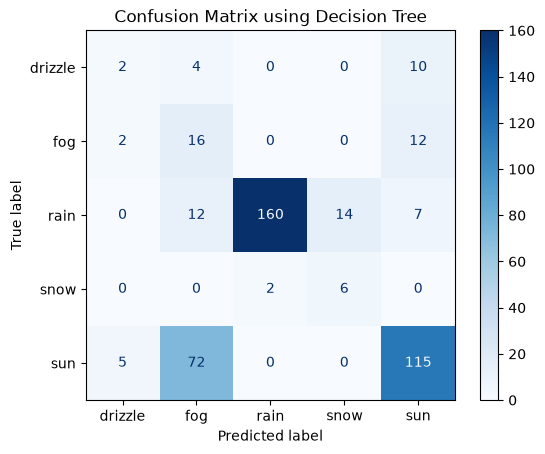

Classification Report using Decision Tree:
              precision    recall  f1-score   support

     drizzle       0.22      0.12      0.16        16
         fog       0.15      0.53      0.24        30
        rain       0.99      0.83      0.90       193
        snow       0.30      0.75      0.43         8
         sun       0.80      0.60      0.68       192

    accuracy                           0.68       439
   macro avg       0.49      0.57      0.48       439
weighted avg       0.81      0.68      0.73       439



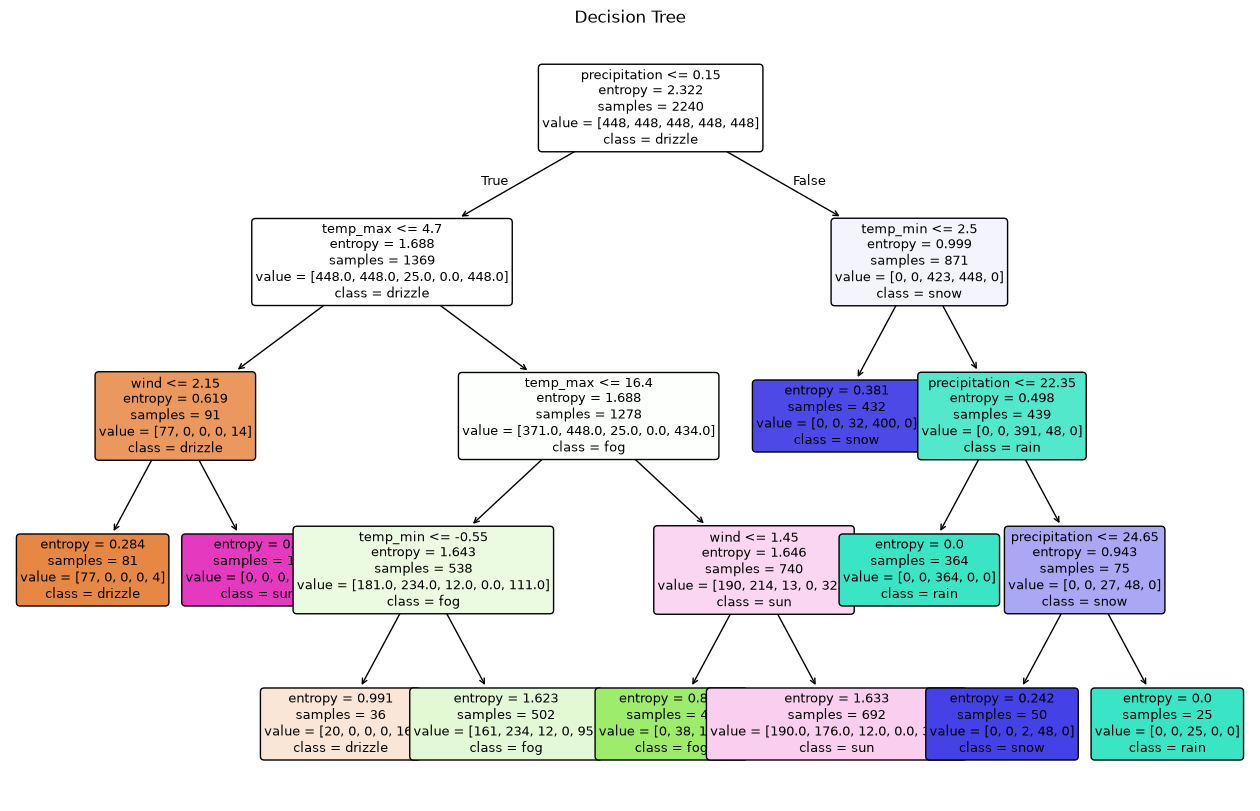

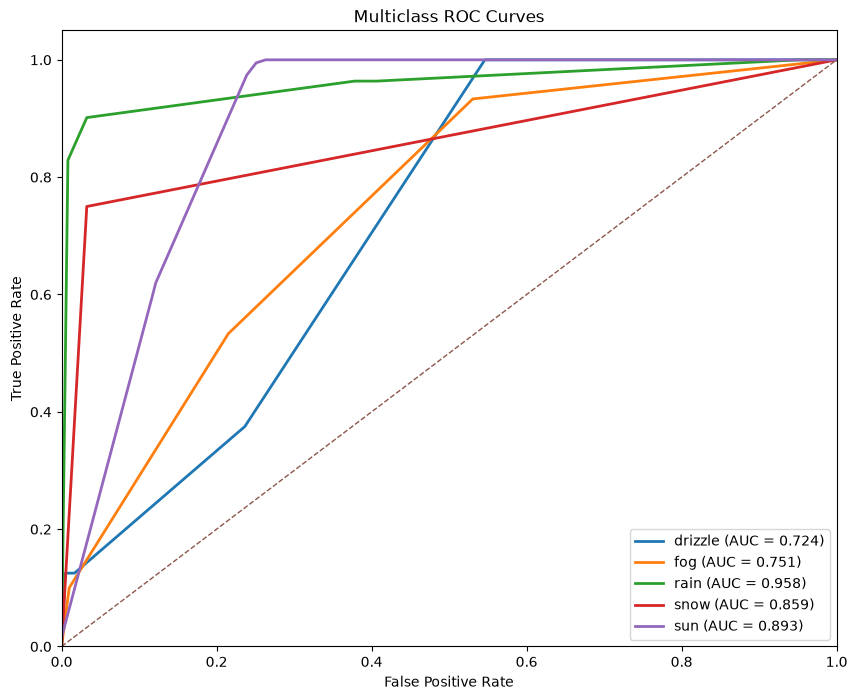

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay,classification_report,roc_curve,auc)
from sklearn.preprocessing import label_binarize
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler


# Display the first few rows of the dataset
print("Dataset successfully loaded!")
print(df.head())

# Remove the variable 'date'
df = df.drop(columns=['date'], errors='ignore')

# Define features/target from the ORIGINAL dataset
# Keep only numeric features for X; 'weather' is the multiclass target
# num_cos selects the names of all columns in df that have numeric data types,
# so they can be used as input features for the model.
num_cols = df.select_dtypes(include='number').columns
X = df[num_cols].copy()
y = df['weather'].copy()

print("\nOriginal class distribution:")
print(y.value_counts())

# Train/test split from the ORIGINAL data
# The test set remains untouched to avoid data leakage
# stratify=y makes the train and test sets preserve approximately the same class proportions
# as the original target variable y, which is especially important in classification problems with class imbalance.
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

# Build a pipeline so balancing happens ONLY inside fit() on the training folds
# This pipeline is built so that the oversampling and the classifier become a single workflow,
# ensuring that RandomOverSampler is applied only to the training folds inside cross-validation before fitting the DecisionTreeClassifier,
# which prevents data leakage and allows GridSearchCV to tune both the balancing strategy and the model hyperparameters correctly.
pipeline = Pipeline(steps=[('sampler', RandomOverSampler(random_state=42)),('model', DecisionTreeClassifier(random_state=42))])

# Hyperparameter optimization with GridSearchCV
# sampler__sampling_strategy tells the model to try two different ways of balancing the classes during training:
# 'not majority' means: increase the samples of all minority classes, but leave the largest class unchanged.
# 'all' means: resample all classes so that they end up with the same size.
param_grid = {'sampler__sampling_strategy': ['not majority', 'all'],
              'model__criterion': ['gini', 'entropy'],'model__max_depth': [2, 3, 4],
    'model__min_samples_split': [2, 4, ],'model__min_samples_leaf': [1, 2, 4],'model__max_features': [None, 'sqrt', 'log2'],
    'model__max_leaf_nodes': [5, 10]}

# 5-fold cross-validation strategy
# shuffle=True means the data are randomly shuffled before being divided into the folds,
#  so the cross-validation splits are more randomized rather than preserving the original order of the dataset.
# The validation set answers the question: Which model configuration seems to perform best?
# The final test set answers the question: How well does the selected model ultimately perform on unseen data?
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search to find the best hyperparameters

## refit=True -> after finding the best hyperparameters, train the model again on the full dataset using those best settings
# n_jobs=None -> use 1 worker by default
# n_jobs=1    -> run without parallelism
# n_jobs=2    -> use 2 CPU workers
# n_jobs=4    -> use 4 CPU workers
# n_jobs=-1   -> use all available CPU workers
grid_search = GridSearchCV(estimator=pipeline,param_grid=param_grid,cv=cv,scoring='balanced_accuracy',n_jobs=-1,verbose=1,refit=True)

##########################################################
# This is just a part of the whole code to see the combinations.
from sklearn.model_selection import ParameterGrid
n_candidates = len(ParameterGrid(param_grid))
print(f"Number of candidates: {n_candidates}")
print(f"Total number of fits with 5-fold CV: {n_candidates * 5}")
##########################################################

# Fitting the X_train and Y_train on the model
grid_search.fit(X_train, y_train)
# Reporting the best hyperparameters
best_model = grid_search.best_estimator_
print("\nBest Hyperparameters:")
print(grid_search.best_params_)
print("\nBest CV Balanced Accuracy:")
print(grid_search.best_score_)

# Predictions, confusion matrix, and classification report
y_pred = best_model.predict(X_test)

# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=best_model.named_steps['model'].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=best_model.named_steps['model'].classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix using Decision Tree")
plt.show()

# Printing the classification report
print("Classification Report using Decision Tree:")
print(classification_report(y_test,y_pred))

# Visualize the optimized decision tree
plt.figure(figsize=(16, 10))
plot_tree(best_model.named_steps['model'],feature_names=X.columns,class_names=[str(c) for c in best_model.named_steps['model'].classes_],
          filled=True, rounded=True,fontsize=9)
plt.title("Decision Tree")
plt.show()

# Multiclass ROC curves (One-vs-Rest)
y_score = best_model.predict_proba(X_test)
classes = best_model.named_steps['model'].classes_
y_test_bin = label_binarize(y_test, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}

for i, class_name in enumerate(classes):
    fpr[class_name], tpr[class_name], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[class_name] = auc(fpr[class_name], tpr[class_name])

plt.figure(figsize=(10, 8))
for class_name in classes:
    plt.plot(fpr[class_name],tpr[class_name],lw=2,label=f"{class_name} (AUC = {roc_auc[class_name]:.3f})"    )

plt.plot([0, 1], [0, 1], linestyle='--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")
plt.legend(loc="lower right")
plt.show()